# FEATURE EXTRACTION FROM RAW TEXT DATA

## 1. Introduction

In this notebook, I work with a dataset from the [Kaggle Playground Series S4E9](https://www.kaggle.com/competitions/playground-series-s4e9).

The focus is on transforming the raw `engine` text column into structured, model-ready features. This column contains multiple technical attributes in a single field, which makes it difficult to use directly in analysis or machine learning models.

Using regular expressions, I extract key engine-related features, measure extraction coverage, validate the results and review records that do not match expected patterns.

## 2. Import Libraries & Load Data

In [1]:
import pandas as pd
import re
df_main_train = pd.read_csv("train.csv")
df = df_main_train.copy()
print(f"Dataset loaded. Shape: {df.shape}")

Dataset loaded. Shape: (188533, 13)


## 3. Understanding the Raw Data: "Engine" Column

In [2]:
pd.set_option("display.max_colwidth", None)
df['engine'].sample(30, random_state=42).reset_index(drop=True)

0                                                     3.5L V6 24V MPFI DOHC
1                              280.0HP 3.9L 8 Cylinder Engine Gasoline Fuel
2                                                      3.6L V6 24V GDI DOHC
3                     320.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel
4                             295.0HP 3.5L V6 Cylinder Engine Gasoline Fuel
5                       250.0HP 5.9L Straight 6 Cylinder Engine Diesel Fuel
6                              170.0HP 2.5L 5 Cylinder Engine Gasoline Fuel
7                              435.0HP 5.0L 8 Cylinder Engine Gasoline Fuel
8                                                       3.6 Liter SIDI DOHC
9                                                3.0L V6 24V GDI DOHC Turbo
10                            306.0HP 3.5L V6 Cylinder Engine Gasoline Fuel
11                            281.0HP 3.6L V6 Cylinder Engine Gasoline Fuel
12                                                     5.7L V8 16V MPFI OHV
13          

### Example (line 22)

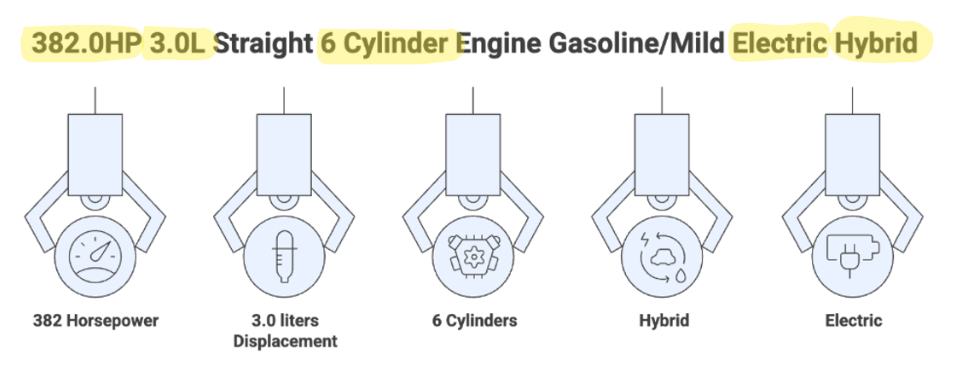

As we can see, the `engine` column contains multiple pieces of information in a single feature. We can extract the following features:

- **engine_hp:** Extracts engine power in horsepower from the raw engine text.
- **engine_displacement_l:** Extracts engine size in liters from the raw engine text.
- **engine_cylinders:** Extracts the number of engine cylinders such as `8 Cylinder`, `V6`, or `I4`.
- **has_turbo:** Indicates if the engine description mentions a turbo engine.
- **has_flex_fuel:** Indicates if the engine description mentions flex-fuel capability.
- **has_hybrid:** Indicates if the engine description mentions hybrid technology.
- **has_electric:** Indicates if the engine description contains electric-related information.

## 4. Extracting Structured Engine Features

My approach:

1. apply a regex pattern to extract the target information,

2. evaluate how much of the data is covered,

3. review unmatched records to identify missing or non-standard formats.

This step-by-step structure ensures that each extracted feature is reliable.

### 4.1. Engine Horsepower

#### 4.1.1. Extraction

In [3]:
df["engine_hp"] = (
    df["engine"]
    .str.extract(r"(\d+(?:\.\d+)?)\s*HP", flags=re.IGNORECASE)[0]
    .astype(float))

df.loc[
    df["engine_hp"].notna(),
    ["engine", "engine_hp"]
].sample(20, random_state=1)

,engine,engine_hp
2246,210.0HP 3.7L V6 Cylinder Engine Gasoline Fuel,210.0
1820,263.0HP 4.7L 8 Cylinder Engine Gasoline Fuel,263.0
146437,220.0HP 2.0L 4 Cylinder Engine Flex Fuel Capability,220.0
153408,170.0HP 2.5L 4 Cylinder Engine Gasoline Fuel,170.0
79752,455.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,455.0
59630,301.0HP 4.6L 8 Cylinder Engine Gasoline Fuel,301.0
93126,600.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,600.0
65263,490.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,490.0
70440,420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,420.0
175212,230.0HP 3.2L Straight 6 Cylinder Engine Gasoline Fuel,230.0


#### 4.1.2. Coverage Check

In [4]:
hp_coverage = pd.DataFrame({
    "metric": [
        "total_rows",
        "engine_hp_extracted",
        "engine_hp_missing_after_extraction"
    ],
    "count": [
        len(df),
        df["engine_hp"].notna().sum(),
        df["engine"].notna().sum() - df["engine_hp"].notna().sum()
    ]
})

hp_coverage["ratio"] = hp_coverage["count"] / len(df)

hp_coverage

,metric,count,ratio
0,total_rows,188533,1.000000
1,engine_hp_extracted,155274,0.823591
2,engine_hp_missing_after_extraction,33259,0.176409


#### 4.1.3. Unmatched Record Review

In [5]:
hp_unmatched = (
    df.loc[
        df["engine"].notna() & df["engine_hp"].isna(),
        "engine"
    ]
    .value_counts()
    .reset_index()
)

hp_unmatched.columns = ["engine", "count"]

hp_unmatched.head(30)

,engine,count
0,2.0L I4 16V GDI DOHC Turbo,2680
1,3.5L V6 24V PDI DOHC Twin Turbo,1842
2,5.7L V8 16V MPFI OHV,1540
3,4.0L V8 32V GDI DOHC Twin Turbo,1516
4,3.6L V6 24V MPFI DOHC,1480
5,3.6L V6 24V GDI DOHC,1224
6,2.0 Liter Turbo,1164
7,5.3L V8 16V GDI OHV,1011
8,–,925
9,2.5L I4 16V GDI DOHC,898


### 4.2. Engine Displacement

#### 4.2.1. Extraction

In [6]:
df["engine_displacement_l"] = (
    df["engine"]
    .str.extract(r"(\d+(?:\.\d+)?)\s*L", flags=re.IGNORECASE)[0]
    .astype(float))

df.loc[
    df["engine_displacement_l"].notna(),
    ["engine", "engine_displacement_l"]
].sample(20, random_state=1)

,engine,engine_displacement_l
41373,490.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,6.2
49651,365.0HP 3.3L V6 Cylinder Engine Gasoline Fuel,3.3
18240,315.0HP 5.3L 8 Cylinder Engine Flex Fuel Capability,5.3
151211,560.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,4.4
54376,3.6L V6 24V MPFI DOHC,3.6
135016,160.0HP 2.4L 4 Cylinder Engine Gasoline Fuel,2.4
182722,375.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,5.0
184292,3.0 Liter,3.0
155700,425.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel,3.0
16112,300.0HP 5.4L 8 Cylinder Engine Gasoline Fuel,5.4


#### 4.2.2. Coverage Check

In [7]:
displacement_coverage = pd.DataFrame({
    "metric": [
        "total_rows",
        "engine_displacement_l_extracted",
        "engine_displacement_l_missing_after_extraction"
    ],
    "count": [
        len(df),
        df["engine_displacement_l"].notna().sum(),
        df["engine"].notna().sum() - df["engine_displacement_l"].notna().sum()
    ]
})

displacement_coverage["ratio"] = displacement_coverage["count"] / len(df)

displacement_coverage

,metric,count,ratio
0,total_rows,188533,1.000000
1,engine_displacement_l_extracted,181835,0.964473
2,engine_displacement_l_missing_after_extraction,6698,0.035527


#### 4.2.3. Unmatched Record Review

In [8]:
displacement_unmatched = (
    df.loc[
        df["engine"].notna() & df["engine_displacement_l"].isna(),
        "engine"
    ]
    .value_counts()
    .reset_index()
)

displacement_unmatched.columns = ["engine", "count"]

displacement_unmatched.head(30)

,engine,count
0,–,925
1,518.0HP Electric Motor Electric Fuel System,826
2,425.0HP Electric Motor Electric Fuel System,732
3,455.0HP Electric Motor Electric Fuel System,533
4,835.0HP Electric Motor Electric Fuel System,522
5,Electric,483
6,670.0HP Electric Motor Electric Fuel System,321
7,Electric Motor Electric Fuel System,269
8,271.0HP Electric Motor Electric Fuel System,241
9,563.0HP Electric Motor Electric Fuel System,194


### 4.3. Engine Cylinders

#### 4.3.1. Extraction

In [9]:
df["engine_cylinders"] = (
    df["engine"]
    .str.extract(r"(?:(\d+)\s*Cylinder|[VI](\d+))", flags=re.IGNORECASE)
    .bfill(axis=1)[0]
    .astype(float))

df.loc[
    df["engine_cylinders"].notna(),
    ["engine", "engine_cylinders"]
].sample(20, random_state=1)

,engine,engine_cylinders
42300,400.0HP 6.0L 8 Cylinder Engine Gasoline Fuel,8.0
184681,393.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,8.0
31733,220.0HP 2.0L 4 Cylinder Engine Flex Fuel Capability,4.0
172641,2.3L I4 16V GDI DOHC Turbo,4.0
70684,302.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6.0
100474,393.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,8.0
144618,611.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,8.0
83610,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,8.0
134252,385.0HP 6.2L 8 Cylinder Engine Flex Fuel Capability,8.0
43624,248.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,4.0


#### 4.3.2. Coverage Check

In [10]:
cylinders_coverage = pd.DataFrame({
    "metric": [
        "total_rows",
        "engine_cylinders_extracted",
        "engine_cylinders_missing_after_extraction"
    ],
    "count": [
        len(df),
        df["engine_cylinders"].notna().sum(),
        df["engine"].notna().sum() - df["engine_cylinders"].notna().sum()
    ]
})

cylinders_coverage["ratio"] = cylinders_coverage["count"] / len(df)

cylinders_coverage

,metric,count,ratio
0,total_rows,188533,1.000000
1,engine_cylinders_extracted,173347,0.919452
2,engine_cylinders_missing_after_extraction,15186,0.080548


#### 4.3.3. Unmatched Record Review

In [11]:
cylinders_unmatched = (
    df.loc[
        df["engine"].notna() & df["engine_cylinders"].isna(),
        "engine"
    ]
    .value_counts()
    .reset_index()
)

cylinders_unmatched.columns = ["engine", "count"]

cylinders_unmatched.head(30)

,engine,count
0,2.0 Liter Turbo,1164
1,–,925
2,518.0HP Electric Motor Electric Fuel System,826
3,3.0 Liter Turbo,823
4,3.0 Liter,748
5,425.0HP Electric Motor Electric Fuel System,732
6,2.0 Liter,636
7,2.0 Liter TFSI,610
8,3.5 Liter,565
9,455.0HP Electric Motor Electric Fuel System,533


### 4.4. Turbo Indicator

#### 4.4.1. Extraction

In [12]:
df["has_turbo"] = (
    df["engine"]
    .str.contains(r"\bTurbo\b", case=False, na=False))

df.loc[
    df["has_turbo"],
    ["engine", "has_turbo"]
].sample(20, random_state=1)

,engine,has_turbo
147118,3.0L H6 24V GDI DOHC Twin Turbo,True
154464,2.0L I4 16V GDI DOHC Turbo,True
139402,6.7L V8 32V DDI OHV Turbo Diesel,True
120377,1.4L I4 16V GDI DOHC Turbo,True
14320,2.0 Liter Turbo,True
114210,4.0L V8 32V GDI DOHC Twin Turbo,True
176771,4.0L V8 32V GDI DOHC Twin Turbo,True
129109,4.4 Liter Twin Turbo,True
114517,1.5L I3 12V PDI DOHC Turbo,True
139743,2.0L I4 16V GDI DOHC Turbo,True


#### 4.4.2. Non-Matching Record Review

In [13]:
turbo_false = (
    df.loc[
        ~df["has_turbo"] & df["engine"].notna(),
        "engine"
    ]
    .value_counts()
    .reset_index()
)

turbo_false.columns = ["engine", "count"]

turbo_false.head(30)

,engine,count
0,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,3462
1,240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,2902
2,420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,2841
3,375.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,2451
4,340.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,2436
5,490.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,2187
6,455.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,2138
7,425.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel,2134
8,300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel,2084
9,295.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,1917


### 4.5. Flex-Fuel Indicator

#### 4.5.1. Extraction

In [14]:
df["has_flex_fuel"] = (
    df["engine"]
    .str.contains(r"\bFlex Fuel\b|\bFlex\b|\bE85\b", case=False, na=False))

df.loc[
    df["has_flex_fuel"],
    ["engine", "has_flex_fuel"]
].sample(20, random_state=1)

,engine,has_flex_fuel
88365,290.0HP 3.6L V6 Cylinder Engine Flex Fuel Capability,True
56179,310.0HP 5.4L 8 Cylinder Engine Flex Fuel Capability,True
142298,208.0HP 2.0L 4 Cylinder Engine Flex Fuel Capability,True
85025,295.0HP 5.3L 8 Cylinder Engine Flex Fuel Capability,True
127884,220.0HP 2.0L 4 Cylinder Engine Flex Fuel Capability,True
167452,290.0HP 3.5L V6 Cylinder Engine Flex Fuel Capability,True
52410,310.0HP 5.4L 8 Cylinder Engine Flex Fuel Capability,True
56623,310.0HP 5.4L 8 Cylinder Engine Flex Fuel Capability,True
73028,403.0HP 6.2L 8 Cylinder Engine Flex Fuel Capability,True
38825,315.0HP 5.3L 8 Cylinder Engine Flex Fuel Capability,True


#### 4.5.2. Non-Matching Record Review

In [15]:
flex_fuel_false = (
    df.loc[
        ~df["has_flex_fuel"] & df["engine"].notna(),
        "engine"
    ]
    .value_counts()
    .reset_index()
)

flex_fuel_false.columns = ["engine", "count"]

flex_fuel_false.head(30)

,engine,count
0,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,3462
1,240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,2902
2,420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,2841
3,2.0L I4 16V GDI DOHC Turbo,2680
4,375.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,2451
5,340.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,2436
6,490.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,2187
7,455.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,2138
8,425.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel,2134
9,300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel,2084


### 4.6. Hybrid Indicator

#### 4.6.1. Extraction

In [16]:
df["has_hybrid"] = (
    df["engine"]
    .str.contains(r"\bHybrid\b", case=False, na=False))

df.loc[
    df["has_hybrid"],
    ["engine", "has_hybrid"]
].sample(20, random_state=1)

,engine,has_hybrid
112460,335.0HP 3.0L V6 Cylinder Engine Gasoline/Mild Electric Hybrid,True
91027,395.0HP 3.0L Straight 6 Cylinder Engine Gasoline/Mild Electric Hybrid,True
38883,305.0HP 3.6L V6 Cylinder Engine Gasoline/Mild Electric Hybrid,True
77061,429.0HP 3.0L Straight 6 Cylinder Engine Gasoline/Mild Electric Hybrid,True
58575,395.0HP 5.7L 8 Cylinder Engine Gasoline/Mild Electric Hybrid,True
107,382.0HP 3.0L Straight 6 Cylinder Engine Gasoline/Mild Electric Hybrid,True
32657,1.6L I4 16V GDI DOHC Turbo Hybrid,True
178625,496.0HP 4.0L 8 Cylinder Engine Gasoline/Mild Electric Hybrid,True
58814,395.0HP 3.0L Straight 6 Cylinder Engine Gasoline/Mild Electric Hybrid,True
2672,285.0HP 3.6L V6 Cylinder Engine Gasoline/Mild Electric Hybrid,True


#### 4.6.2. Non-Matching Record Review

In [17]:
hybrid_false = (
    df.loc[
        ~df["has_hybrid"] & df["engine"].notna(),
        "engine"
    ]
    .value_counts()
    .reset_index()
)

hybrid_false.columns = ["engine", "count"]

hybrid_false.head(30)

,engine,count
0,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,3462
1,240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,2902
2,420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,2841
3,2.0L I4 16V GDI DOHC Turbo,2680
4,375.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,2451
5,340.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,2436
6,490.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,2187
7,455.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,2138
8,425.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel,2134
9,300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel,2084


### 4.7. Electric Indicator

#### 4.7.1. Extraction

In [18]:
df["has_electric"] = (
    df["engine"]
    .str.contains(r"\bElectric\b", case=False, na=False))

df.loc[
    df["has_electric"],
    ["engine", "has_electric"]
].sample(20, random_state=1)

,engine,has_electric
177485,835.0HP Electric Motor Electric Fuel System,True
95850,208.0HP 2.5L 4 Cylinder Engine Gas/Electric Hybrid,True
118490,480.0HP Electric Motor Electric Fuel System,True
31966,455.0HP Electric Motor Electric Fuel System,True
100203,533.0HP Electric Motor Electric Fuel System,True
98817,518.0HP Electric Motor Electric Fuel System,True
106815,335.0HP 3.0L V6 Cylinder Engine Gasoline/Mild Electric Hybrid,True
26205,425.0HP Electric Motor Electric Fuel System,True
50194,134.0HP 1.8L 4 Cylinder Engine Gas/Electric Hybrid,True
69305,416.0HP Electric Motor Electric Fuel System,True


#### 4.7.2. Non-Matching Record Review

In [19]:
electric_false = (
    df.loc[
        ~df["has_electric"] & df["engine"].notna(),
        "engine"
    ]
    .value_counts()
    .reset_index()
)

electric_false.columns = ["engine", "count"]

electric_false.head(30)

,engine,count
0,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,3462
1,240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,2902
2,420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,2841
3,2.0L I4 16V GDI DOHC Turbo,2680
4,375.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,2451
5,340.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,2436
6,490.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,2187
7,455.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,2138
8,425.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel,2134
9,300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel,2084


## 5. Extraction Coverage Summary

Feature extraction is done.

Here we see how much of the dataset is covered by each extracted feature. This provides a clear view of how effective the extraction is and highlights any areas where information may still be missing. It tells us if further extraction is needed.

In [20]:
feature_coverage = pd.DataFrame({
    "feature": [
        "engine_hp",
        "engine_displacement_l",
        "engine_cylinders",
        "has_turbo",
        "has_flex_fuel",
        "has_hybrid",
        "has_electric"
    ],
    "matched_count": [
        df["engine_hp"].notna().sum(),
        df["engine_displacement_l"].notna().sum(),
        df["engine_cylinders"].notna().sum(),
        df["has_turbo"].sum(),
        df["has_flex_fuel"].sum(),
        df["has_hybrid"].sum(),
        df["has_electric"].sum()
    ]
})

feature_coverage["matched_ratio"] = feature_coverage["matched_count"] / len(df)
feature_coverage["matched_percentage"] = (feature_coverage["matched_ratio"] * 100).round(2).astype(str) + "%"

feature_coverage

,feature,matched_count,matched_ratio,matched_percentage
0,engine_hp,155274,0.823591,82.36%
1,engine_displacement_l,181835,0.964473,96.45%
2,engine_cylinders,173347,0.919452,91.95%
3,has_turbo,14270,0.075690,7.57%
4,has_flex_fuel,5168,0.027412,2.74%
5,has_hybrid,5531,0.029337,2.93%
6,has_electric,11139,0.059082,5.91%


## 6. Extracted Feature Validation

This stage is based on domain knowledge. Extracted features are checked for unrealistic or out-of-range values. 

Here we look for values that do not make sense. This helps confirm that the extraction logic is working as expected.

In [21]:
validation_summary = pd.DataFrame({
    "check": [
        "horsepower_below_50",
        "horsepower_above_1500",
        "displacement_below_0_5",
        "displacement_above_10",
        "cylinders_below_2",
        "cylinders_above_16"
    ],
    "count": [
        (df["engine_hp"] < 50).sum(),
        (df["engine_hp"] > 1500).sum(),
        (df["engine_displacement_l"] < 0.5).sum(),
        (df["engine_displacement_l"] > 10).sum(),
        (df["engine_cylinders"] < 2).sum(),
        (df["engine_cylinders"] > 16).sum()
    ]
})

validation_summary["ratio"] = validation_summary["count"] / len(df)
validation_summary["percentage"] = (validation_summary["ratio"] * 100).round(2).astype(str) + "%"

validation_summary

,check,count,ratio,percentage
0,horsepower_below_50,0,0.0,0.0%
1,horsepower_above_1500,0,0.0,0.0%
2,displacement_below_0_5,0,0.0,0.0%
3,displacement_above_10,0,0.0,0.0%
4,cylinders_below_2,0,0.0,0.0%
5,cylinders_above_16,0,0.0,0.0%


## 7. Final Engine Text Quality Check

Now we check the rows where **no information** was extracted.

These are the records where all numeric features are missing and all indicator features are false.

### 7.1. Unmatched Record Summary

In [22]:
numeric_features_missing = df[
    ["engine_hp", "engine_displacement_l", "engine_cylinders"]
].isna().all(axis=1)

indicator_features_false = (
    ~df["has_turbo"] &
    ~df["has_flex_fuel"] &
    ~df["has_hybrid"] &
    ~df["has_electric"])

unmatched_engine_rows = df[
    df["engine"].notna() &
    numeric_features_missing &
    indicator_features_false]

unmatched_engine_check = pd.DataFrame({
    "metric": [
        "total_rows",
        "fully_unmatched_engine_rows"
    ],
    "count": [
        len(df),
        len(unmatched_engine_rows)
    ]
})

unmatched_engine_check["ratio"] = unmatched_engine_check["count"] / len(df)
unmatched_engine_check["percentage"] = (unmatched_engine_check["ratio"] * 100).round(2).astype(str) + "%"

unmatched_engine_check

,metric,count,ratio,percentage
0,total_rows,188533,1.000000,100.0%
1,fully_unmatched_engine_rows,1093,0.005797,0.58%


### 7.2. Unmatched Engine Details

In [23]:
unmatched_engine_summary = (
    unmatched_engine_rows["engine"]
    .value_counts()
    .reset_index()
)

unmatched_engine_summary.columns = ["engine", "count"]

unmatched_engine_summary["ratio"] = unmatched_engine_summary["count"] / len(df)
unmatched_engine_summary["percentage"] = (unmatched_engine_summary["ratio"] * 100).round(2).astype(str) + "%"

unmatched_engine_summary

,engine,count,ratio,percentage
0,–,925,0.004906,0.49%
1,Dual Motor - Standard,117,0.000621,0.06%
2,Standard Range Battery,39,0.000207,0.02%
3,111.2Ah / FR 70kW / RR 160kW (697V),8,0.000042,0.0%
4,120 AH,4,0.000021,0.0%


## 8. Conclusion

The final quality check showed that only 0.58% of the records remained fully unmatched after the extraction process.

As a result, the raw text column was transformed into structured, reliable, and model-ready data for analysis and machine learning.

## 9. Where This Approach Can Be Applied

This approach can be applied to any dataset especially in cases include:

* product specifications
* equipment data
* log records
* customer descriptions
* operational text fields
* text data cleaning tasks

The same pipeline can be reused to turn similar unstructured text into clean, model-ready data.